# **What is CycleGAN?**

**CycleGAN** was proposed in a [2020 Paper](https://arxiv.org/abs/1703.10593?amp=1).

$Intution :$
The main idea of **Cycle GAN** is to utilize the power of **Unpaired Data**, i.e. the Datasets in which the **Inputs and the Labels** are **not directly Related.** A classic example of this is, **Neural Style Transfer**, where **one Input** is an **Image** and the **Other image** is generally a **Painting signifying the Style** to be used. The netework tries to **fuse both the Images** and the main goal is to **Preserve the Spatial Information of the Original Image but apply the Style of the Painting**. The **CycleGAN** have the **same goal** but the **Archictecture** proposed in **one of its kind**.

---
The **application of Cycle GAN** is **more diverse** than **NST**. You can use **Cycle GAN** for $:$

* Conversion between **Monet images to realistic photographs**. 
* converting **Day to Night images**.
* Going from **winter images to summer images**.
* Not only that, you can create a **custom Snapchat filter** for yourself that can change **your face to anything that you can imagine**.

> One of the **most interesting application** that **I found** was. Merging images of two or more people together to produce a single image of a person having characteristic of all the people. 

> After this notebook, I'm pretty sure that I'm going to come up with 10-15 more notebooks on **Cycle GAN**, covering almost all the applications that I found to be interesting or something like magic.

One of the **main profit** of **Cycle GAN** is that you don't need paired data. This means you can, basically collect data from Internet without even worrying about matching your labels with your features. 

---
The **Cycle GAN** paper introduces 2 new terms for us, 

* **Cycle Consistency** $:$ I will explain it with respect to architecture in a bit. If you look at it from a mathematical point of view. Then we can say that If there exists a function $F(x) : X -> Y$ , then in another function $G(Y) : Y -> X$. In our case, consider $F(X)$ and $G(Y)$ as **Discriminators**. We want to maintain the *Cycle Consistency*, i.e. $G(F(X)) = X$. 

* **Identity** $:$ In simple words, if Y is fed to $F(X)$ then the output should be $Y$ itself.


---
Let's look as the **Model Architecture** $:$

* cycle can consist of 2 **generators** and 2 **discriminators**. 
 
 * The task of one of the generator is to generate type B images from type A images. So if this generator is a function $F(X)$, it goes from $X$ to $Y$.

 * the task of the **second generator** is to **regenerate** the **type A image from type B images**. 

**But why do we even need two different generators?**

Let's try to answer this question using an example, our is convert horse images to zebra images.

* The first question then you need to answer is how to actually train the generator. We don't have the label images with the same spatial information as the input images. Then, even if the model generates something, how would you know that the generation is actually correct?. 

That's why we have **2 generators**, 1 generator mapping from **Horse images** to **zebra images** and the $2^n$$^d$ generator mapping from **zebra images to horse images**. Here, we introduce a **cycle loss**. That simply means, if the **input image** and the **final output image** after going through both the generators are not same, we will punish the model. This way we encourage the first generator to maintain the spatial information of the original image, but still try to replace a horse from a zebra. The $2^n$$^d$ generator is helpful for applying this process. 


As we know, in order to encourage the models to produce the right mask, we need discriminator. That's why we have two different discriminators, one discriminator for each generator. The discriminator architecture is exactly the same as that of the **Pix2Pix Patch GAN Discriminator**. 

> One of the major differences that the model does not use is **batch normalization**. Instead it uses **Instance normalization**. This forces each of the **feature map** to contain as much information as possible about **spatial data** as well as **the transforming information**.

This way the whole model has two different generators and two different discriminators. In total, the model has four different losses. 

1. Cycle Loss
2. Identity Loss
3. Discriminator 1 Loss
4. Discriminator 2 Loss

---
$Remark :$

A **complete forward cycle** means going from **photo to mapping**, then again from **mapping to the photo**.

A **complete backward cycle** means going from **mapping to photo**, and then from **photo to mapping**. 

The **identity** with respect to **generator means** that, If a **mapping image** is passed to the **first generator** then it should return the **same image** without much transformation. This is because it is trained to convert photo to the mapping, but the input is already in mapping so it does not needs to be converted. The same goes for the second generator.

---

If you're not aware about Pix2Pix GAN, I have covered it in [this notebook](https://www.kaggle.com/code/utkarshsaxenadn/pix2pixgan-map-generatorhttps://www.kaggle.com/code/utkarshsaxenadn/pix2pixgan-map-generator).

---

There is **no major difference between** the generation of **Pix2Pix GAN** and **Cycle GAN**. The **major advantage** with **Cycle GAN** is that you **don't need paired images**. That actually **reduces the stress** onf the data set create. If you have ever created a data set, You know what I mean. 

---
But that doesn't mean that **Cycle GAN** is the king of **all GANs**. There are some cases when even **Cycle GAN fails**.

# **Imports**

We know that **Cycle GAN** uses **Instance normalization**. But it is not available with **keras**. Don't worry, it is available in **Tensorflow addons**.

In [4]:
from IPython.display import clear_output as clear
!pip install tensorflow-addons
clear()

Let's import all the other libraries that will be needed in this notebook.

In [5]:
# Common
import os
import keras
import numpy as np
from glob import glob
from tqdm import tqdm
import tensorflow as tf
from random import random

# Data
import tensorflow.image as tfi
import matplotlib.pyplot as plt
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

# Model Layers
from keras.layers import ReLU
from keras.layers import Input
from keras.layers import Conv2D
from keras.layers import Dropout
from keras.layers import LeakyReLU
from keras.layers import Activation
from keras.layers import concatenate
from keras.layers import ZeroPadding2D
from keras.layers import Conv2DTranspose
from tensorflow_addons.layers import InstanceNormalization

# Model Functions
from keras.models import Model
from keras.models import load_model
from keras.models import Sequential
from keras.initializers import RandomNormal

# Optimizers
from tensorflow.keras.optimizers import Adam

# Loss
from keras.losses import BinaryCrossentropy

# Model Viz
from tensorflow.keras.utils import plot_model

You can make all the imports in a single line, but I made them in different lines because that just looks good.

# **Custom Functions**

In [6]:
def show_image(image, title=None):
    '''
    The function takes in an image and plots it using Matplotlib.
    '''
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')

In [7]:
import pandas as pd
import os
import shutil

# Step 1: Read the dataset
dataset_path = '/kaggle/input/celeba-dataset/list_attr_celeba.csv'
df = pd.read_csv(dataset_path)

# Step 2: Filter the dataset based on attributes "Male" and "Eyeglasses"
male_eye_glasses = df[(df['Male'] == 1) & (df['Eyeglasses'] == 1)]
male_no_eye_glasses = df[(df['Male'] == 1) & (df['Eyeglasses'] == -1)]
female_eye_glasses = df[(df['Male'] == -1) & (df['Eyeglasses'] == 1)]
female_no_eye_glasses = df[(df['Male'] == -1) & (df['Eyeglasses'] == -1)]

# Step 3: Randomly shuffle the filtered datasets
male_eye_glasses = male_eye_glasses.sample(frac=1).reset_index(drop=True)
male_no_eye_glasses = male_no_eye_glasses.sample(frac=1).reset_index(drop=True)
female_eye_glasses = female_eye_glasses.sample(frac=1).reset_index(drop=True)
female_no_eye_glasses = female_no_eye_glasses.sample(frac=1).reset_index(drop=True)

# Step 4: Split the datasets into four parts
split_size = len(male_eye_glasses) // 4
parts = [
    male_eye_glasses[:split_size],
    male_no_eye_glasses[:split_size],
    female_eye_glasses[:split_size],
    female_no_eye_glasses[:split_size]
]

# Step 5: Store each part in the working directory
output_directory = '/kaggle/working/dataset_splits'
os.makedirs(output_directory, exist_ok=True)

for i, part in enumerate(parts):
    part.to_csv(os.path.join(output_directory, f'part_{i+1}.csv'), index=False)

# Optionally, if you want to move images corresponding to the data, you can do it like this:
# Assuming the images are in a folder named 'images' and the 'image_id' column contains image filenames
for i, part in enumerate(parts):
    image_folder = f'/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba'
    target_folder = os.path.join(output_directory, f'part_{i+1}_images')
    os.makedirs(target_folder, exist_ok=True)
    for filename in part['image_id']:
        shutil.copy(os.path.join(image_folder, filename), target_folder)


# **Data**

In [8]:
root_men_glasses_path = '/kaggle/working/dataset_splits/part_1_images'
root_mwg_path = '/kaggle/working/dataset_splits/part_2_images'
root_women_glasses_path = '/kaggle/working/dataset_splits/part_4_images'
root_wwg_path = '/kaggle/working/dataset_splits/part_3_images'
mg_paths = sorted(glob(root_men_glasses_path + '/*.jpg'))[:1000]
mwg_paths = sorted(glob(root_mwg_path + '/*.jpg'))[:1000]
wg_paths = sorted(glob(root_women_glasses_path + '/*.jpg'))[:1000]
wwg_paths = sorted(glob(root_wwg_path + '/*.jpg'))[:1000]

In total there are **1067 images**.

The number of Images is perfect for the **Kaggle RAM** with respect to the **number of images dataset** have. This is because, if you have seen my other **Pix2Pix GAN** notebooks then you would have recognized that I generally use **1000 images** for training with **256 size** and in this data set, that's the **default case**.

In [9]:
SIZE = 256
part1_images = np.zeros((len(mg_paths), SIZE, SIZE, 3))
part2_images = np.zeros((len(mwg_paths), SIZE, SIZE, 3))
part3_images = np.zeros((len(wg_paths), SIZE, SIZE, 3))
part4_images = np.zeros((len(wwg_paths), SIZE, SIZE, 3))

# Function to load and preprocess images
def load_and_preprocess_image(image_path):
    image = img_to_array(load_img(image_path))
    image = tf.image.resize(tf.cast(image, tf.float32) / 255., (SIZE, SIZE))
    return image

# Loading images for part 1
for i, image_path in tqdm(enumerate(mg_paths), desc='Loading Part 1'):
    part1_images[i] = load_and_preprocess_image(image_path)

# Loading images for part 2
for i, image_path in tqdm(enumerate(mwg_paths), desc='Loading Part 2'):
    part2_images[i] = load_and_preprocess_image(image_path)

# Loading images for part 3
for i, image_path in tqdm(enumerate(wg_paths), desc='Loading Part 3'):
    part3_images[i] = load_and_preprocess_image(image_path)

# Loading images for part 4
for i, image_path in tqdm(enumerate(wwg_paths), desc='Loading Part 4'):
    part4_images[i] = load_and_preprocess_image(image_path)

Loading Part 1: 1000it [00:06, 159.65it/s]
Loading Part 2: 1000it [00:06, 158.63it/s]
Loading Part 3: 1000it [00:06, 159.16it/s]
Loading Part 4: 1000it [00:06, 160.65it/s]


Great, all the **images are loaded**. Let's visualize some of them.

In [10]:
dataset = [part1_images, part2_images, part3_images, part4_images]

# **Data Viz**

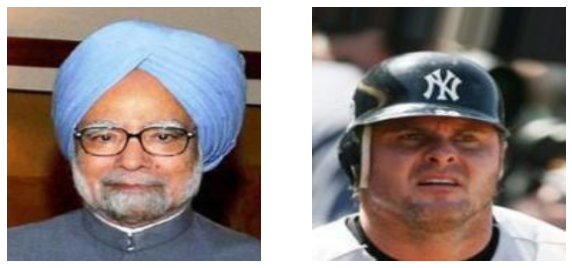

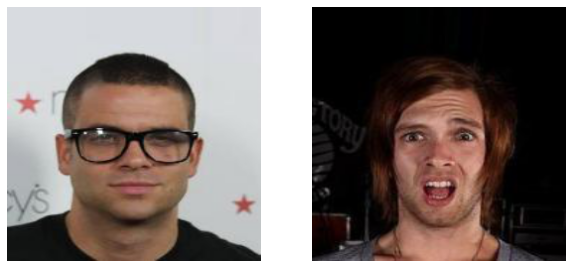

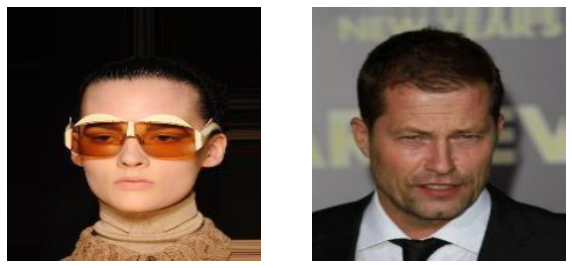

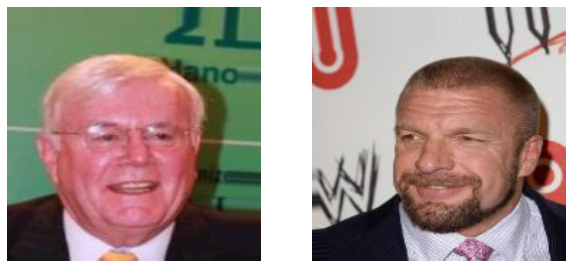

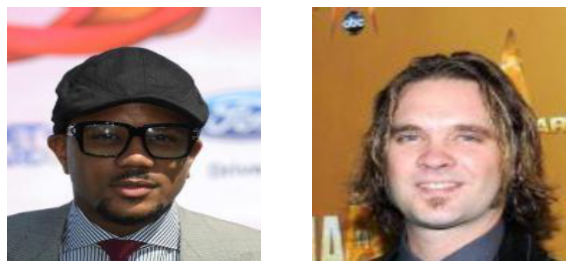

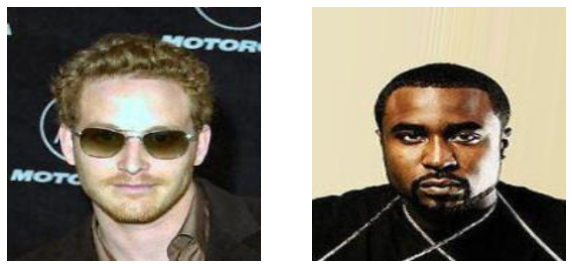

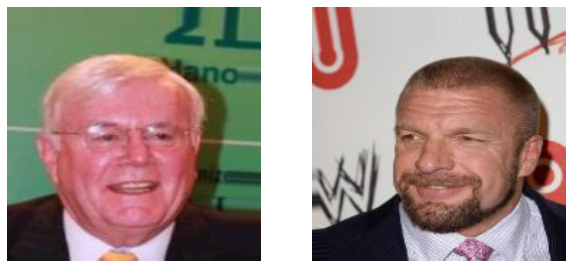

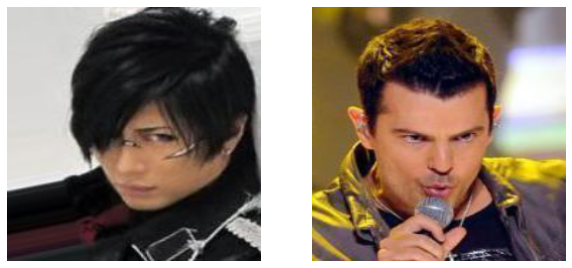

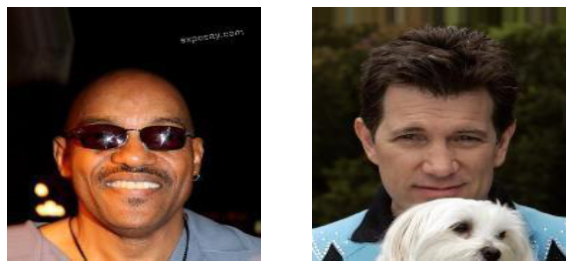

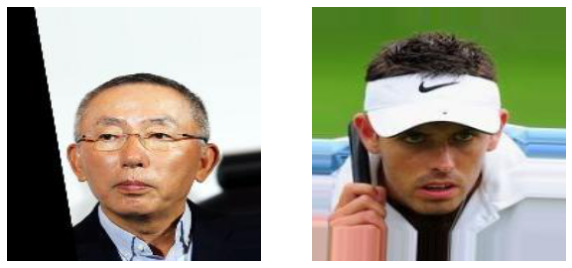

In [11]:
# Visualizing
for i in range(10):
    id = np.random.randint(len(part1_images))
    mg,mwg,wg,wwg = part1_images[id], part2_images[id],part3_images[id],part4_images[id]
    
    plt.figure(figsize=(10,8))
    
    plt.subplot(1,2,1)
    show_image(mg)
    
    plt.subplot(1,2,2)
    show_image(mwg)
    plt.show()

As you can easily notice, there is **no direct relation** between **horses and zebras** with respect to the images we are going to feed into the model. So somehow the model will have to understand the **actual important information** about **horses and zebras**, and at the same time it should also learn to **transform a horse to a zebra or zebra to a horse**. This seems to be a tough task, and Indeed it is. That's why a new **architecture was proposed to solve the problem**.

# **Generator**

The **overall generator** is the same as the **previous generator** used in **pixel to pixel GAN**, but this time the generator has a **New Residual block**. Let's create this **Residual Block**, this **residual block** has the **2 set** **Convolutional layer** followed by **instance normalization**, which is in last followed by a **Skip Connection**.

In [12]:
def ResidualBlock(filters, layer, index):
#     init = RandomNormal(stddev=0.02)
    
    x = Conv2D(filters, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', use_bias=False, name="Block_{}_Conv1".format(index))(layer)
    x = InstanceNormalization(axis=-1, name="Block_{}_Normalization1".format(index))(x)
    x = ReLU(name="Block_{}_ReLU".format(index))(x)
    
    x = Conv2D(filters, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', use_bias=False, name="Block_{}_Conv2".format(index))(x)
    x = InstanceNormalization(axis=-1, name="Block_{}_Normalization2".format(index))(x)
    
    x = concatenate([x, layer], name="Block_{}_Merge".format(index))
    
    return x

The **residual network** uses a **stride = 1**. That means it does **not decreases** the **size of the input image**. All it does is it **learns the features of the image**.

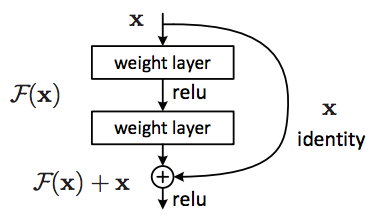

Let's create the **main model architecture**.

In [13]:
def downsample(filters, layer, size=3, strides=2, activation=None, index=None, norm=True):
    x = Conv2D(filters, kernel_size=size, strides=strides, padding='same', kernel_initializer='he_normal', use_bias=False, name="Encoder_{}_Conv".format(index))(layer)
    if norm:
        x = InstanceNormalization(axis=-1, name="Encoder_{}_Normalization".format(index))(x)
    if activation is not None:
        x = Activation(activation, name="Encoder_{}_Activation".format(index))(x)
    else:
        x = LeakyReLU( name="Encoder_{}_LeakyReLU".format(index))(x)
    return x

The **downsample layer**, will simply **decrease the size of the input image by 2**.

In [14]:
def upsample(filters, layer, size=3, strides=2, index=None):
    x = Conv2DTranspose(filters, kernel_size=size, strides=strides, padding='same', kernel_initializer='he_normal', use_bias=False, name="Decoder_{}_ConvT".format(index))(layer)
    x = InstanceNormalization(axis=-1, name="Decoder_{}_Normalization".format(index))(x)
    x = ReLU( name="Encoder_{}_ReLU".format(index))(x)
    return x

**Upsample** will perform the **exact opposite** and will **increase the image size by 2**.

In [15]:
def Generator(n_resnet=9, name="Generator"):
    
    inp_image = Input(shape=(SIZE, SIZE, 3), name="InputImage")         # 256 x 256 x3
    
    x = downsample(64, inp_image, size=7, strides=1, index=1)           # 256 x 256 x 64
    x = downsample(128, x, index=2)                                     # 128 x 128 x 128
    x = downsample(256, x, index=3)                                     # 64 x 64 x 256
    
    for i in range(n_resnet):
        x = ResidualBlock(256, x, index=i+4)                             # (64 x 64 x 256) x n_resnet
    
    x = upsample(128, x, index=13)                                       # 128 x 128 x 128
    x = upsample(64, x, index=14)                                        # 256 x 256 x 64
    x = downsample(3, x, size=7, strides=1, activation='tanh', index=15) # 256 x 256 x 3
    
    model = Model(
        inputs=inp_image,
        outputs=x,
        name=name
    )
    return model

The **final generator** is basically the **combination of down sample layers**, **upsample layers** and most importantly the **residual block layers**. The main function of **residual block layers** is to actually learn the **hidden patterns in the data**. In our case, that means to learn **what a horse looks like** and **what a zebra looks like**. So our generator is ready, let's move towards the **discriminator**.

# **Discriminator**

As I mentioned, the **discriminator** is **exactly the same** as the one we have previously used in **pixel to pixel GAN**. The only thing we need to keep in mind is that instead of using **batch normalization**, we need to use **instance normalization**.

In [16]:
def Discriminator(name='Discriminator'):
    init = RandomNormal(stddev=0.02)
    src_img = Input(shape=(SIZE, SIZE, 3), name="InputImage")     # 256 x 256 x 3
    x = downsample(64, src_img, size=4, strides=2, index=1, norm=False) # 128 x 128 x 64
    x = downsample(128, x, size=4, strides=2, index=2)            # 64 x 64 x 128
    x = downsample(256, x, size=4, strides=2, index=3)            # 32 x 32 x 256
    x = downsample(512, x, size=4, strides=2, index=4)            # 16 x 16 x 512
    x = downsample(512, x, size=4, strides=2, index=5)            # 8 x 8 x 512  # we can try out a different architecture with zero padding layer.
    patch_out = Conv2D(1, kernel_size=4, padding='same', kernel_initializer=init, use_bias=False)(x) # 8 x 8 x 1
    
    model = Model(
        inputs=src_img,
        outputs=patch_out,
        name=name
    )
    model.compile(
        loss='mse',
        optimizer=Adam(learning_rate=2e-4, beta_1=0.5),
        loss_weights=[0.5]
    )
    return model

The **main function** of **discriminator** is to actually learn whether the **generated images** are actually **generated from the input image** or not. That means the **spatial dimensions** of the **input image** and the **generated image** should be the same. While the information they contain **should be different**.

# **Training Functions**

In [17]:
def CombineModel(g_model1, g_model2, d_model, name):
    # train the Generator
    g_model1.trainable = True

    # Stop the Discriminator and 2nd Generator
    d_model.trainable = False
    g_model2.trainable = False
    
    # Adversarial Loss
    input_gen = Input(shape=(SIZE, SIZE, 3))
    gen_1_out = g_model1(input_gen)
    dis_out = d_model(gen_1_out)
    
    # Identity Loss
    input_id = Input(shape=(SIZE, SIZE, 3))
    output_id = g_model1(input_id)
    
    # Cycle Loss - Forward
    output_f = g_model2(gen_1_out)
    
    # Cycle Loss - Backward
    gen_2_out = g_model2(input_id)
    output_b = g_model1(gen_2_out)
    
    # Final Model 
    model = Model(
        inputs=[input_gen, input_id],
        outputs=[dis_out, output_id, output_f, output_b],
        name=name
    )
    model.compile(
        loss=['mse', 'mae', 'mae', 'mae'],
        loss_weights=[1,5,10,10],
        optimizer= Adam(learning_rate=2e-4, beta_1=0.5)
    )
    return model

As you can see that this **combined model function** simply takes in the **generator** and the **discriminator** and combine them. To make a **single model**, This will help us during the **training process**.

In [18]:
def generate_real_samples(n_samples, dataset):
    ix = np.random.randint(0,dataset.shape[0], n_samples)
    X = dataset[ix]
    y = np.ones(shape=(n_samples, 8, 8, 1))
    return X, y

In [19]:
def generate_fake_samples(g_model, dataset):
    # Ensure that the dataset has the correct shape
    if len(dataset.shape) == 3:
        dataset = np.expand_dims(dataset, axis=0)  # Add batch dimension if missing

    # Reshape the dataset to match the expected input shape of the generator
    dataset_resized = tf.image.resize(dataset, [256, 256])  # Resize images to 256x256

    # Predict fake samples using the generator model
    X = g_model.predict(dataset_resized)

    # For the labels, assuming binary classification (real/fake), set all labels to fake (0)
    y = np.zeros(shape=(len(X), 8, 8, 1))  # Adjust shape according to your label format
    return X, y



All these functions are self-explanatory.

In [20]:
def update_image_pool(pool, images, max_size=50):
    selected = list()
    for image in images:
        if len(pool) < max_size:
            pool.append(image)
            selected.append(image)
        elif random() < 0.5:
            selected.append(image)
        else:
            ix = np.random.randint(0,len(pool))
            selected.append(pool[ix])
            pool[ix] = image
    return np.asarray(selected)

Actually, the **authors** created a pool of **50 images**. So they don't just feed the **current image** to the **discriminator and the generator**, but they actually feed the **pool of images**. That's why we have created this pool. I recommend you checking this out in the original paper.

In [21]:

def show_preds(g_AB, g_BA, part1_images, part2_images, part3_images, part4_images, n_images=1):
    for i in range(n_images):
        # Randomly select an image from each part
        part1_id = np.random.randint(len(part1_images))
        part2_id = np.random.randint(len(part2_images))
        part3_id = np.random.randint(len(part3_images))
        part4_id = np.random.randint(len(part4_images))
        
        # Get images from each part
        part1_image, part2_image, part3_image, part4_image = part1_images[part1_id], part2_images[part2_id], part3_images[part3_id], part4_images[part4_id]
        
        # Generate fake images
        part1_fake = g_BA.predict(tf.expand_dims(part1_image, axis=0))[0]
        part2_fake = g_BA.predict(tf.expand_dims(part2_image, axis=0))[0]
        part3_fake = g_BA.predict(tf.expand_dims(part3_image, axis=0))[0]
        part4_fake = g_BA.predict(tf.expand_dims(part4_image, axis=0))[0]
        
        # Display images
        plt.figure(figsize=(20, 8))
        
        plt.subplot(4, 4, 1)
        show_image(part1_image, title='Original Part 1')
        
        plt.subplot(4, 4, 2)
        show_image(part1_fake, title='Generated Part 1 (Zebra)')
        
        plt.subplot(4, 4, 3)
        show_image(part2_image, title='Original Part 2')
        
        plt.subplot(4, 4, 4)
        show_image(part2_fake, title='Generated Part 2 (Zebra)')
        
        plt.subplot(4, 4, 5)
        show_image(part3_image, title='Original Part 3')
        
        plt.subplot(4, 4, 6)
        show_image(part3_fake, title='Generated Part 3 (Zebra)')
        
        plt.subplot(4, 4, 7)
        show_image(part4_image, title='Original Part 4')
        
        plt.subplot(4, 4, 8)
        show_image(part4_fake, title='Generated Part 4 (Zebra)')
        
        plt.tight_layout()
        plt.show()


In [22]:
def train(d_model_A, d_model_B, gen_AB, gen_BA, c_AB, c_BA, dataset1, dataset2, epochs=10, chunk=5):
    
    n_epochs, n_batch = epochs, 1
    
    trainA, trainB = dataset1, dataset2
    poolA, poolB = list(), list()
    
    # in simple words, we are going through the whole data.
    bat_per_epoch1 = int(len(trainA)/n_batch)
    bat_per_epoch2 = int(len(trainB)/n_batch)
    n_steps1 = bat_per_epoch1
    n_steps2 = bat_per_epoch2
    
    for j in tqdm(range(1, epochs+1), desc="Epochs"):
        for i in range(max(n_steps1, n_steps2)):
            
            # Training on dataset1 (Men without glasses and men with glasses)
            if i < n_steps1:
                X_realA, y_realA = generate_real_samples(n_batch, trainA)
                X_realB, y_realB = generate_real_samples(n_batch, trainA)  # Reusing dataset1 for B
                
                # use our generators to generate some fake data.
                X_fakeA, y_fakeA = generate_fake_samples(gen_BA, X_realB)
                X_fakeB, y_fakeB = generate_fake_samples(gen_AB, X_realA)
                
                # create a pool of images. You can also understand it like a replay buffer.
                X_fakeA = update_image_pool(poolA, X_fakeA)
                X_fakeB = update_image_pool(poolB, X_fakeB)
                
                # Let's finally train the gen_BA and get the losses.
                gen_loss2, _, _, _, _ = c_BA.train_on_batch(
                    [X_realB, X_realA],
                    [y_realB, X_realA, X_realB, X_realA]
                )
                
                # It's time for our discriminator to win our generator.
                dA_loss_1 = d_model_A.train_on_batch(X_realA, y_realA)
                dA_loss_2 = d_model_A.train_on_batch(X_fakeA, y_fakeA)
            
            # Training on dataset2 (Men with glasses and women with glasses)
            if i < n_steps2:
                X_realA, y_realA = generate_real_samples(n_batch, trainB)  # Reusing dataset2 for A
                X_realB, y_realB = generate_real_samples(n_batch, trainB)
                
                # use our generators to generate some fake data.
                X_fakeA, y_fakeA = generate_fake_samples(gen_BA, X_realB)
                X_fakeB, y_fakeB = generate_fake_samples(gen_AB, X_realA)
                
                # create a pool of images. You can also understand it like a replay buffer.
                X_fakeA = update_image_pool(poolA, X_fakeA)
                X_fakeB = update_image_pool(poolB, X_fakeB)
                
                # Let's finally train the gen_AB and get the losses.
                gen_loss1, _, _, _, _ = c_AB.train_on_batch(
                    [X_realA, X_realB],
                    [y_realA, X_realB, X_realA, X_realB]
                )
                
                # again, let's give some power to our discriminators.
                dB_loss_1 = d_model_B.train_on_batch(X_realB, y_realB)
                dB_loss_2 = d_model_B.train_on_batch(X_fakeB, y_fakeB)

        if (j % chunk) == 0:
            # Test the model
            print("Testing the model...")
            test_model(gen_AB, gen_BA, test_dataset1, test_dataset2)
            
            # Save models
            gen_AB.save(f"GeneratorHtoZ_{j}.h5")
            gen_BA.save(f"GeneratorZtoH_{j}.h5")


# **Training**

In [23]:
# let's create our generators.
g_AB = Generator(name="GeneratorAB")
g_BA = Generator(name="GeneratorBA")

# here are the respective discriminators.
d_A = Discriminator(name="DiscriminatorA")
d_B = Discriminator(name="DiscriminatorB")

# finally, let's combine all of them.
c_AB = CombineModel(g_AB, g_BA, d_B, name="GanAB")
c_BA = CombineModel(g_BA, g_AB, d_A, name="GanBA")

I have used the name **A&B** so that the model can be **generalized to any data set**.

In [24]:
# Assuming you have defined your generators, discriminators, and combined models

# Initialize your datasets (replace with actual data loading)
dataset1 = [part1_images, part2_images]
dataset2 = [part1_images, part3_images]

dataset1 = np.array(dataset1)
dataset2 = np.array(dataset2)
# Call the train function
train(d_A, d_B, g_AB, g_BA, c_AB, c_BA, dataset1, dataset2, epochs=100, chunk=5)


Epochs:   0%|          | 0/100 [00:07<?, ?it/s]


ValueError: 'images' must have either 3 or 4 dimensions.

In [ ]:
# g_AB.save("GeneratorHtoZ.h5")
# g_BA.save("GeneratorZtoH.h5")

If you are looking for a **much better control** over your **training**, then please use a **lower value of chunk**. the training will **take time** because for **each epoch** the model is going through **1067 images** and even storing the **replay buffer**. So you can understand that's a lot of work to do.

---
$Quick Tip :$
* Creating an **actual replay buffer** in **Tensorflow** will help **optimizing Training**. Which will finally result in a **faster training**.

---
$Observations :$

* During the **initial epochs**, you can **clearly notice** how the model tries to **clear the pixels** of **horses and zebras**, and even **learns to identify their location**.

* After training for a few epochs. You will encounter a state where the model will be able to convert the **colors of horses and zebras**. Personally, it feels very overwhelming to see that the model is actually able to perform it.

* After training the model for **25 epochs**. The generator that converts **horse to zebra** was **next to perfect**.

* At the same time, the second generator was still struggling. The model was able to **colour the zebra** but was not able to **get rid of these scales**.

---
$Remainder :$
* It took me **8 hours and 50 minutes** to train the model for **25 Epochs**. So always keep in mind that *GAN** will take **Exceptional amount of time** as well as **very large datasets** for **performing well**.

Model After **25 Epochs** $:$

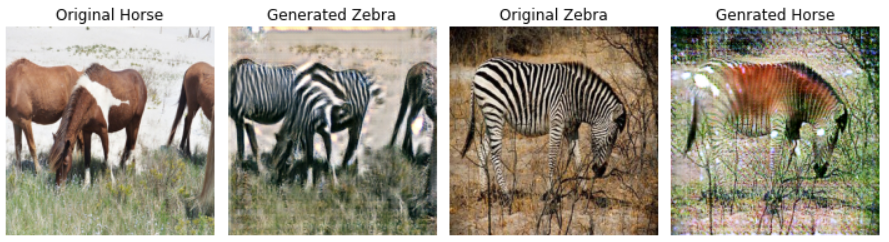

# **Evaluation**

In [ ]:
HtoZ_gen = load_model("../input/imagetoimage-translation-cyclegan/GeneratorHtoZ.h5")
ZtoH_gen = load_model("../input/imagetoimage-translation-cyclegan/GeneratorZtoH.h5")

In [ ]:

show_preds(g_AB, g_BA, part1_images, part2_images, part3_images, part4_images, n_images=1)


In [ ]:
HtoZ_gen_25 = load_model("../input/imagetoimage-translation-cyclegan/GeneratorHtoZ_25.h5")
ZtoH_gen_25 = load_model("../input/imagetoimage-translation-cyclegan/GeneratorZtoH_25.h5")

These are the model weights of 25th epoch. Which I found to be the best model in terms of horse to zebra generator.

In [ ]:
# Assuming you have your generators gen_AB and gen_BA already defined, and you have your dataset loaded
# You need to pass the generators and the dataset to show_preds

# Example call
show_preds(g_AB, g_BA, part1_images, part2_images, part3_images, part4_images, n_images=5)


$Observations :$

* The **zebra to horse Generator** was amazing at the time of initial training. It is performing bad now. This could be the result of **unstable training**.

* The **horse generator** is still trying to just **color out the zebra,** and it's pretty bad at it.

* The **horse to Zebra generator** is good, at least it's performing something, but it **loses a lot of spatial information** during transformation.

* The **25th Epoch Horse to Zebra generator** is somehow better than the other **Horse to Zebra generator**.

* The good thing is that the first generator has **not only learned to change the color, but also to add scales**.

---
The models are not perfect yet. They are just trained for 25 epochs. Which took around 12 hours. Now your job is to train them for the remaining 75 epochs. And I can guarantee that the model performance will boost up. 

These images shows the potential of **cycle GAN**. By enough training, **cycle GAN** could be perfect.

---
$Suggestion :$

* **GAN** requires a **lot of data** and a **lot of training** time in order to perform job **exceptionally good**. I was lacking the hardware. If you have the **perfect hardware**, I recommend you to **train it for more epochs**, at least for 50(You can use the **pre trained weights of 25 epochs**, so now you just have to **train it for 25 more**.).

---
Let me know your suggestions in the comments.

**Thanks !!!**

---
**DeepNets**